## Importing libraries

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,mean_absolute_error,mean_squared_error,r2_score


# Relationship Between Features

## 1. Energy Consumption (kWh) ↔ CO₂ Emissions (kg)
- There is generally a **positive relationship** between Energy Consumption and CO₂ Emissions.
- Higher energy usage usually results in higher carbon emissions.
- This relationship is important because reducing energy consumption can lower environmental impact.

---

## 2. Transport Distance (km) ↔ CO₂ Emissions (kg)
- Transport Distance is expected to have a **positive correlation** with CO₂ Emissions.
- Longer transportation routes consume more fuel and produce more greenhouse gases.

---

## 3. Transport Distance (km) ↔ Delivery Time (days)
- Products transported over longer distances generally require more delivery time.
- This relationship helps evaluate supply chain efficiency.

---

## 4. Waste Generation (kg) ↔ Sustainability Score
- Waste Generation usually has a **negative relationship** with Sustainability Score.
- Higher waste production reduces environmental sustainability.

---

## 5. Recycling Rate (%) ↔ Sustainability Score
- Recycling Rate has a **positive relationship** with Sustainability Score.
- Companies with better recycling practices are generally more sustainable.

---

## 6. Energy Consumption (kWh) ↔ Sustainability Score
- Increased Energy Consumption may reduce Sustainability Score if the energy source is not renewable.
- Lower energy usage generally indicates better resource efficiency.

---

## 7. CO₂ Emissions (kg) ↔ Sustainability Score
- Higher CO₂ Emissions generally lead to a lower Sustainability Score.
- Reducing emissions improves overall sustainability performance.

---

## 8. Waste Generation (kg) ↔ Recycling Rate (%)
- Companies with higher recycling rates often generate less unrecycled waste.
- Therefore, these variables may show a negative relationship.

---

## 9. Product Type ↔ Sustainability Score
- Different Product Types may have different sustainability performances.
- Some products require more energy and transportation than others.

---

## 10. Product Type ↔ Energy Consumption
- Manufacturing requirements vary by product type.
- Some product categories naturally consume more energy during production.

---

In [8]:
df=pd.read_csv(r"C:\Users\rishi\Downloads\green_supply_chain_dataset.csv")
df.head()

,ID,Product_Type,Raw_Material_Usage_kg,Energy_Consumption_kWh,Waste_Generated_kg,Transport_Distance_km,CO2_Emissions_kg,Manufacturing_Energy_kWh,Renewable_Energy_%,Cost_$,Delivery_Time_days,Sustainability_Score
0,1,Pharmaceutical,187.102474,372.345525,4.580997,2708.230192,206.072501,195.022097,77.312801,4696.896464,2.0,81.25
1,2,Food,117.375305,82.437951,31.494820,605.998543,794.003359,784.206729,31.899124,989.721787,4.0,37.55
2,3,Automotive,142.363657,82.065527,49.077714,945.366997,166.372969,775.047264,16.863118,1321.186084,2.0,41.17
3,4,Food,185.274882,55.448814,10.315275,2883.074057,653.161326,214.610271,46.877202,1464.672539,1.0,56.79
4,5,Food,144.375341,480.425629,39.837161,1552.152306,167.653725,309.596187,13.996935,381.536655,10.0,45.27


### Dataset Understanding
Review `df.info()`, `df.describe()`, and `df.isnull().sum()` to understand datatypes, distributions, and missing values.

In [9]:
df.info()
display(df.describe(include='all'))
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        1000 non-null   int64  
 1   Product_Type              1000 non-null   object 
 2   Raw_Material_Usage_kg     996 non-null    float64
 3   Energy_Consumption_kWh    991 non-null    float64
 4   Waste_Generated_kg        998 non-null    float64
 5   Transport_Distance_km     991 non-null    float64
 6   CO2_Emissions_kg          993 non-null    float64
 7   Manufacturing_Energy_kWh  994 non-null    float64
 8   Renewable_Energy_%        998 non-null    float64
 9   Cost_$                    998 non-null    float64
 10  Delivery_Time_days        995 non-null    float64
 11  Sustainability_Score      996 non-null    float64
dtypes: float64(10), int64(1), object(1)
memory usage: 93.9+ KB


,ID,Product_Type,Raw_Material_Usage_kg,Energy_Consumption_kWh,Waste_Generated_kg,Transport_Distance_km,CO2_Emissions_kg,Manufacturing_Energy_kWh,Renewable_Energy_%,Cost_$,Delivery_Time_days,Sustainability_Score
count,1000.000000,1000,996.000000,991.000000,998.000000,991.000000,993.000000,994.000000,998.000000,998.000000,995.000000,996.000000
unique,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Electronics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,210,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,500.500000,NaN,104.897840,274.291534,25.418484,2503.680767,523.332113,447.408142,44.132690,2501.951879,7.672362,51.221114
std,288.819436,NaN,55.622915,130.143277,14.077265,1400.920562,274.989544,202.449387,20.015088,1365.801310,4.028219,14.791439
min,1.000000,NaN,10.880084,50.060612,1.000570,100.150522,50.896245,100.999840,10.016870,201.166085,1.000000,12.800000
25%,250.750000,NaN,54.537821,166.747253,13.140431,1313.722279,285.250061,272.165701,26.809788,1310.754957,4.000000,40.137500
50%,500.500000,NaN,105.452303,275.180516,25.601655,2470.632445,514.595980,445.104492,44.008122,2386.374971,8.000000,50.880000
75%,750.250000,NaN,151.152321,388.580677,37.667331,3672.710051,760.144605,629.441196,60.425428,3646.931791,11.000000,61.922500


ID                          0
Product_Type                0
Raw_Material_Usage_kg       4
Energy_Consumption_kWh      9
Waste_Generated_kg          2
Transport_Distance_km       9
CO2_Emissions_kg            7
Manufacturing_Energy_kWh    6
Renewable_Energy_%          2
Cost_$                      2
Delivery_Time_days          5
Sustainability_Score        4
dtype: int64

### Handle Missing Values
Numeric columns use median; categorical columns use mode.

In [11]:
num=df.select_dtypes(include='number').columns
cat=df.select_dtypes(exclude='number').columns
for c in num: df[c]=df[c].fillna(df[c].median())
for c in cat: df[c]=df[c].fillna(df[c].mode()[0])

### Visualizations

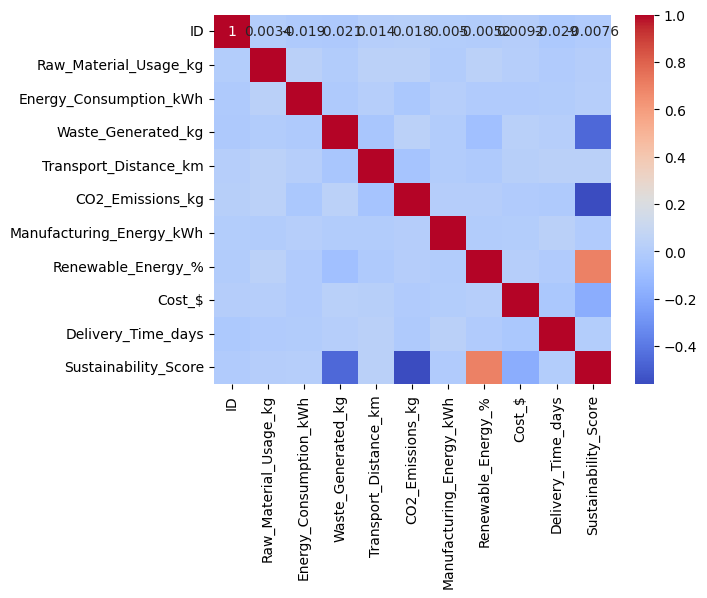

C:\Users\rishi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


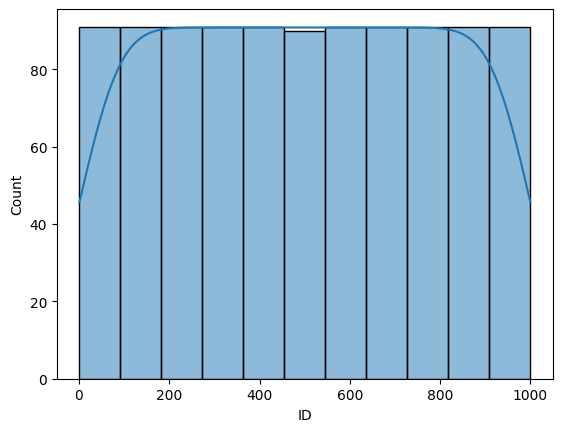

C:\Users\rishi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


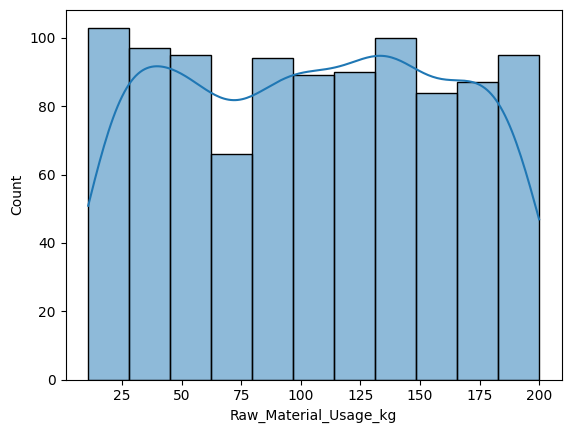

C:\Users\rishi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


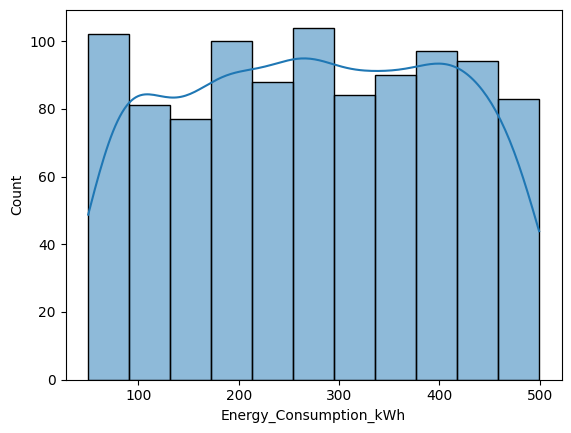

C:\Users\rishi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


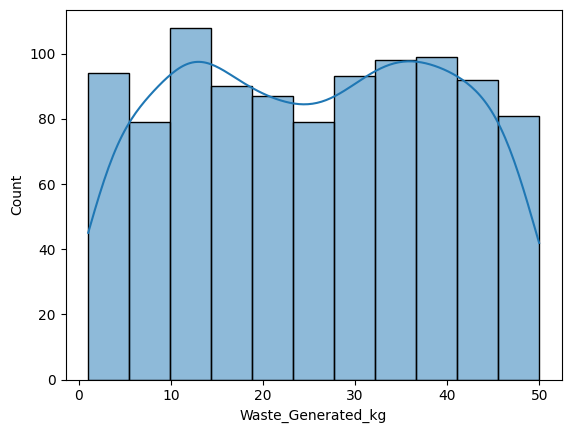

In [13]:
sns.heatmap(df[num].corr(),annot=True,cmap='coolwarm')
plt.show()
for c in num[:4]:
    sns.histplot(df[c],kde=True)
    plt.show()

### Feature Engineering & Encoding

In [15]:
df=pd.get_dummies(df,drop_first=True)
target='Sustainability_Score'
X=df.drop(columns=[target])
y_reg=df[target]
y_cls=(y_reg>=y_reg.median()).astype(int)
scaler=StandardScaler()
X=pd.DataFrame(scaler.fit_transform(X),columns=X.columns)

### Train/Test Split

In [16]:
Xtr,Xte,yrtr,yrte=train_test_split(X,y_reg,test_size=0.2,random_state=42)
_,_,yctr,ycte=train_test_split(X,y_cls,test_size=0.2,random_state=42)

### Logistic Regression

Accuracy 0.99
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        92
           1       0.99      0.99      0.99       108

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



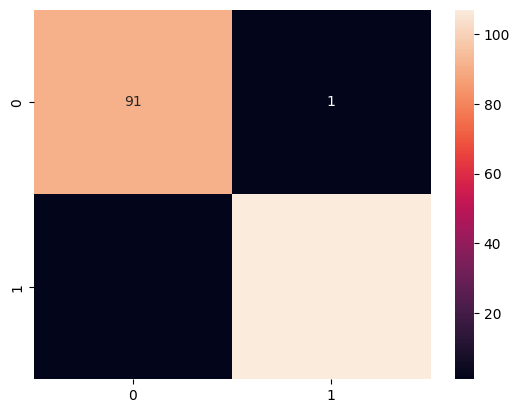

In [19]:
Xtr,Xte,ytr,yte=train_test_split(X,y_cls,test_size=0.2,random_state=42)
log=LogisticRegression(max_iter=1000)
log.fit(Xtr,ytr)
p=log.predict(Xte)
print('Accuracy',accuracy_score(yte,p))
print(classification_report(yte,p))
sns.heatmap(confusion_matrix(yte,p),annot=True,fmt='d')
plt.show()

## Insights
- Median imputation is robust to outliers.
- One-hot encoding avoids imposing false order on categories.
- Standardization helps Logistic Regression converge.
- Correlation heatmap identifies relationships among numeric variables.
- Classification metrics: higher accuracy/F1 indicate better class prediction.
- Compare train/test performance to check for overfitting.